# Notebook 02 — Feature Engineering & Preprocessing

**Goal:** Transform raw IEEE-CIS transaction data into a clean, 
model-ready feature set based on insights from EDA.

## Engineering Plan
1. Drop high-missing features (>90%)
2. Extract time-based features from TransactionDT
3. Log-transform skewed TransactionAmt
4. Create has_identity binary flag
5. Encode categorical features
6. Impute missing values
7. Build sklearn preprocessing pipeline
8. Save processed dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries loaded successfully")

All libraries loaded successfully


## 1. Load Raw Data

In [2]:
# Load raw data
train_transaction = pd.read_csv('../data/raw/train_transaction.csv')
train_identity = pd.read_csv('../data/raw/train_identity.csv')

# Merge
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print("Data loaded and merged successfully")
print(f"Shape: {df.shape}")

Data loaded and merged successfully
Shape: (590540, 434)


## 2. Drop High-Missing Features (>90%)

In [3]:
# Calculate missing percentage for each column
missing_percent = (df.isnull().sum() / len(df)) * 100

# Identify features to drop
cols_to_drop = missing_percent[missing_percent > 90].index.tolist()

print("Features to Drop (>90% missing)")
print("-" * 50)
for col in cols_to_drop:
    print(f"{col}: {missing_percent[col]:.2f}%")

# Drop them
df.drop(columns=cols_to_drop, inplace=True)

print()
print(f"Dropped {len(cols_to_drop)} features")
print(f"Remaining Shape: {df.shape}")

Features to Drop (>90% missing)
--------------------------------------------------
dist2: 93.63%
D7: 93.41%
id_07: 99.13%
id_08: 99.13%
id_18: 92.36%
id_21: 99.13%
id_22: 99.12%
id_23: 99.12%
id_24: 99.20%
id_25: 99.13%
id_26: 99.13%
id_27: 99.12%

Dropped 12 features
Remaining Shape: (590540, 422)


### Observation
After merging transaction and identity data, 12 features exceeded 
the 90% missing threshold (vs 2 identified in EDA on transaction 
data alone). The additional high-missing features are identity 
columns (id_07, id_08, id_18, id_21 through id_27) which are 
sparsely populated across transactions. Dropping these reduces 
noise without losing meaningful signal.

## 3. Time-Based Feature Extraction

In [4]:
# TransactionDT is seconds elapsed from a reference point
# Extract meaningful time-based features

df['hour']        = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['day_of_month']= (df['TransactionDT'] // (3600 * 24)) % 30
df['week']        = (df['TransactionDT'] // (3600 * 24 * 7)) % 52

# Verify
print("Time-Based Features Created")
print("-" * 50)
print(df[['TransactionDT', 'hour', 'day_of_week', 
          'day_of_month', 'week']].head(10).to_string())
print()
print("Hour Range       :", df['hour'].min(), "-", df['hour'].max())
print("Day of Week Range:", df['day_of_week'].min(), "-", df['day_of_week'].max())
print("Week Range       :", df['week'].min(), "-", df['week'].max())

# Fraud rate by hour — verify our EDA finding
print()
print("Fraud Rate by Hour (Top 5)")
print("-" * 50)
print((df.groupby('hour')['isFraud'].mean() * 100).sort_values(
       ascending=False).head(5).round(2).to_string())

Time-Based Features Created
--------------------------------------------------
   TransactionDT  hour  day_of_week  day_of_month  week
0          86400     0            1             1     0
1          86401     0            1             1     0
2          86469     0            1             1     0
3          86499     0            1             1     0
4          86506     0            1             1     0
5          86510     0            1             1     0
6          86522     0            1             1     0
7          86529     0            1             1     0
8          86535     0            1             1     0
9          86536     0            1             1     0

Hour Range       : 0 - 23
Day of Week Range: 0 - 6
Week Range       : 0 - 26

Fraud Rate by Hour (Top 5)
--------------------------------------------------
hour
7   10.6100
8    9.3000
9    9.0000
6    7.7700
5    7.0300


### Observation
Time-based features successfully extracted from TransactionDT. 
Hour ranges 0-23 and day of week 0-6 are confirmed valid. 

An important distinction from EDA: while fraud transaction 
volume peaks at 23:00, fraud RATE (probability of fraud given 
a transaction) is highest in early morning hours — hour 7 
(10.61%), hour 8 (9.30%), and hour 9 (9.00%). This suggests 
fraudsters operate in low-traffic early morning windows where 
fraud rate is high despite lower absolute volume. Hour of day 
is confirmed as a strong feature for modeling.

## 4. Log-Transform TransactionAmt

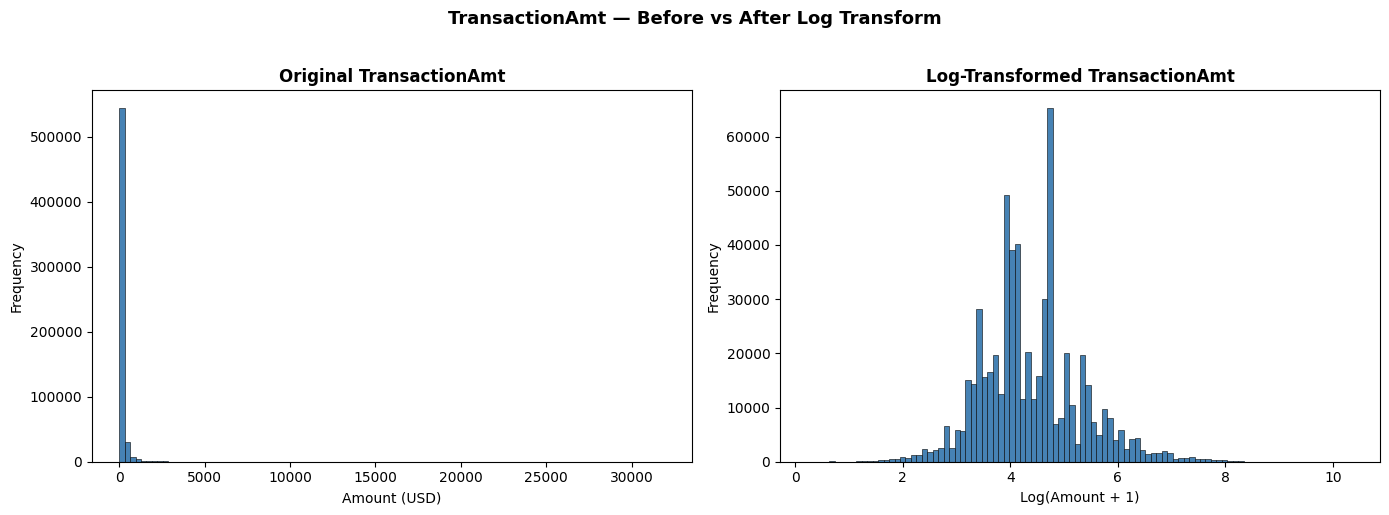

Log Transform Summary
--------------------------------------------------
Original  — Skewness: 14.3745
Transformed — Skewness: 0.4883
Original  — Mean: $135.03
Transformed — Mean: 4.3830


In [5]:
# Log transform to handle right skew
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['TransactionAmt'], bins=100,
             color='steelblue', edgecolor='black', linewidth=0.4)
axes[0].set_title('Original TransactionAmt', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['TransactionAmt_log'], bins=100,
             color='steelblue', edgecolor='black', linewidth=0.4)
axes[1].set_title('Log-Transformed TransactionAmt', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('TransactionAmt — Before vs After Log Transform',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log Transform Summary")
print("-" * 50)
print(f"Original  — Skewness: {df['TransactionAmt'].skew():.4f}")
print(f"Transformed — Skewness: {df['TransactionAmt_log'].skew():.4f}")
print(f"Original  — Mean: ${df['TransactionAmt'].mean():.2f}")
print(f"Transformed — Mean: {df['TransactionAmt_log'].mean():.4f}")

### Observation
Log transformation using log1p reduced TransactionAmt skewness 
from 14.3745 to 0.4883 — a 96.6% reduction. The original 
distribution was extremely right-skewed with most transactions 
clustered near zero and a long tail up to $31,937. After 
transformation the distribution is approximately normal, 
which will improve model convergence and reduce the influence 
of extreme outliers during training.

## 5. Create has_identity Binary Flag

In [6]:
# Create binary flag — 1 if transaction has identity data, 0 if not
df['has_identity'] = df['DeviceType'].notna().astype(int)

print("has_identity Feature Created")
print("-" * 50)
print(f"With Identity    : {df['has_identity'].sum():,} ({df['has_identity'].mean()*100:.2f}%)")
print(f"Without Identity : {(df['has_identity']==0).sum():,} ({(df['has_identity']==0).mean()*100:.2f}%)")
print()

# Check if has_identity correlates with fraud
print("Fraud Rate by has_identity")
print("-" * 50)
print((df.groupby('has_identity')['isFraud'].mean() * 100).round(4).to_string())

has_identity Feature Created
--------------------------------------------------
With Identity    : 140,810 (23.84%)
Without Identity : 449,730 (76.16%)

Fraud Rate by has_identity
--------------------------------------------------
has_identity
0   2.1017
1   7.9618


### Observation
The has_identity binary flag reveals a strong fraud signal — 
transactions WITH identity data have a fraud rate of 7.96% 
compared to only 2.10% for transactions WITHOUT identity data. 
This is counterintuitive at first glance but makes sense in 
context — fraudsters often use devices and identities that 
leave digital footprints, while routine legitimate transactions 
may not capture identity metadata. This 3.8x difference makes 
has_identity one of the most informative engineered features.

## 6. Encode Categorical Features

In [7]:
# Categorical columns to encode
cat_cols = ['ProductCD', 'card4', 'card6', 
            'P_emaildomain', 'R_emaildomain',
            'DeviceType', 'DeviceInfo',
            'id_12', 'id_15', 'id_16', 
            'id_23', 'id_27', 'id_28', 'id_29',
            'id_30', 'id_31', 'id_33', 'id_34',
            'id_35', 'id_36', 'id_37', 'id_38',
            'M1', 'M2', 'M3', 'M4', 'M5', 
            'M6', 'M7', 'M8', 'M9']

# Only encode columns that exist after dropping high-missing ones
cat_cols = [col for col in cat_cols if col in df.columns]

print("Encoding Categorical Features")
print("-" * 50)

le = LabelEncoder()
for col in cat_cols:
    # Fill NaN with 'unknown' before encoding
    df[col] = df[col].fillna('unknown')
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded: {col}")

print()
print(f"Total categorical features encoded: {len(cat_cols)}")

Encoding Categorical Features
--------------------------------------------------
Encoded: ProductCD
Encoded: card4
Encoded: card6
Encoded: P_emaildomain
Encoded: R_emaildomain
Encoded: DeviceType
Encoded: DeviceInfo
Encoded: id_12
Encoded: id_15
Encoded: id_16
Encoded: id_28
Encoded: id_29
Encoded: id_30
Encoded: id_31
Encoded: id_33
Encoded: id_34
Encoded: id_35
Encoded: id_36
Encoded: id_37
Encoded: id_38
Encoded: M1
Encoded: M2
Encoded: M3
Encoded: M4
Encoded: M5
Encoded: M6
Encoded: M7
Encoded: M8
Encoded: M9

Total categorical features encoded: 29


### Observation
29 categorical features successfully label encoded. id_23 and id_27 
were automatically excluded as they were dropped in the high-missing 
feature removal step. NaN values were filled with 'unknown' before 
encoding to preserve the missingness as a separate category rather 
than losing that signal entirely.

## 7. Impute Missing Values

In [8]:
# Separate features and target
target = df['isFraud']
drop_cols = ['isFraud', 'TransactionID', 'TransactionDT', 'TransactionAmt']
feature_df = df.drop(columns=drop_cols)

# Check remaining missing values
remaining_missing = feature_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining Missing Values Before Imputation")
print("-" * 50)
print(f"Features with missing values: {len(remaining_missing)}")
print(f"Total missing cells         : {remaining_missing.sum():,}")
print()

# Impute numerical features with median
num_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
cat_encoded_cols = feature_df.select_dtypes(exclude=[np.number]).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
feature_df[num_cols] = num_imputer.fit_transform(feature_df[num_cols])

# Verify
remaining_after = feature_df.isnull().sum().sum()
print("After Imputation")
print("-" * 50)
print(f"Total missing cells: {remaining_after:,}")
print(f"Shape              : {feature_df.shape}")

Remaining Missing Values Before Imputation
--------------------------------------------------
Features with missing values: 374
Total missing cells         : 98,430,831

After Imputation
--------------------------------------------------
Total missing cells: 0
Shape              : (590540, 424)


### Observation
Median imputation successfully handled 98,430,831 missing cells 
across 374 features. Median was chosen over mean to avoid the 
influence of outliers which are prevalent in financial transaction 
data. Final feature matrix contains 590,540 rows and 424 features 
with zero missing values — ready for modeling.

## 8. Final Feature Set

In [9]:
print("Final Feature Set Summary")
print("-" * 50)
print(f"Total Samples          : {feature_df.shape[0]:,}")
print(f"Total Features         : {feature_df.shape[1]}")
print(f"Missing Values         : {feature_df.isnull().sum().sum():,}")
print()

# Engineered features added
print("Engineered Features Added")
print("-" * 50)
engineered = ['hour', 'day_of_week', 'day_of_month', 
              'week', 'TransactionAmt_log', 'has_identity']
for feat in engineered:
    print(f"  + {feat}")

print()
print("Features Removed")
print("-" * 50)
print("  - TransactionDT   (replaced by time features)")
print("  - TransactionAmt  (replaced by log version)")
print("  - TransactionID   (identifier, not a feature)")
print("  - isFraud         (target variable)")
print("  - 12 high-missing features (>90% missing)")
print()
print("Target Distribution")
print("-" * 50)
print(f"Legitimate : {(target==0).sum():,} ({(target==0).mean()*100:.2f}%)")
print(f"Fraudulent : {(target==1).sum():,} ({(target==1).mean()*100:.2f}%)")

Final Feature Set Summary
--------------------------------------------------
Total Samples          : 590,540
Total Features         : 424
Missing Values         : 0

Engineered Features Added
--------------------------------------------------
  + hour
  + day_of_week
  + day_of_month
  + week
  + TransactionAmt_log
  + has_identity

Features Removed
--------------------------------------------------
  - TransactionDT   (replaced by time features)
  - TransactionAmt  (replaced by log version)
  - TransactionID   (identifier, not a feature)
  - isFraud         (target variable)
  - 12 high-missing features (>90% missing)

Target Distribution
--------------------------------------------------
Legitimate : 569,877 (96.50%)
Fraudulent : 20,663 (3.50%)


## 9. Train/Test Split & Save Processed Data

In [10]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    feature_df, 
    target, 
    test_size=0.2, 
    random_state=42,
    stratify=target
)

print("Train/Test Split Summary")
print("-" * 50)
print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")
print()
print("Fraud Distribution — Train Set")
print(f"Legitimate : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"Fraudulent : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print()
print("Fraud Distribution — Test Set")
print(f"Legitimate : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)")
print(f"Fraudulent : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")

# Save processed data
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print()
print("Processed data saved to data/processed/")

Train/Test Split Summary
--------------------------------------------------
X_train Shape : (472432, 424)
X_test Shape  : (118108, 424)
y_train Shape : (472432,)
y_test Shape  : (118108,)

Fraud Distribution — Train Set
Legitimate : 455,902 (96.50%)
Fraudulent : 16,530 (3.50%)

Fraud Distribution — Test Set
Legitimate : 113,975 (96.50%)
Fraudulent : 4,133 (3.50%)

Processed data saved to data/processed/


## 10. Phase 2 Summary

In [11]:
print("=" * 60)
print("PHASE 2 SUMMARY — Feature Engineering & Preprocessing")
print("=" * 60)
print()
print("Steps Completed")
print("-" * 40)
print("1. Dropped 12 features with >90% missing values")
print("2. Extracted 4 time features from TransactionDT")
print("   - hour, day_of_week, day_of_month, week")
print("3. Log-transformed TransactionAmt")
print("   - Skewness reduced: 14.37 -> 0.49 (96.6% reduction)")
print("4. Created has_identity binary flag")
print("   - Fraud rate: 7.96% (with) vs 2.10% (without)")
print("5. Label encoded 29 categorical features")
print("6. Median imputed 98,430,831 missing cells")
print("7. Stratified 80/20 train/test split")
print()
print("Final Dataset")
print("-" * 40)
print(f"Training Samples  : 472,432")
print(f"Test Samples      : 118,108")
print(f"Total Features    : 424")
print(f"Missing Values    : 0")
print()
print("Next Step")
print("-" * 40)
print("Phase 3 — Model Training + MLflow Experiment Tracking")
print("=" * 60)

PHASE 2 SUMMARY — Feature Engineering & Preprocessing

Steps Completed
----------------------------------------
1. Dropped 12 features with >90% missing values
2. Extracted 4 time features from TransactionDT
   - hour, day_of_week, day_of_month, week
3. Log-transformed TransactionAmt
   - Skewness reduced: 14.37 -> 0.49 (96.6% reduction)
4. Created has_identity binary flag
   - Fraud rate: 7.96% (with) vs 2.10% (without)
5. Label encoded 29 categorical features
6. Median imputed 98,430,831 missing cells
7. Stratified 80/20 train/test split

Final Dataset
----------------------------------------
Training Samples  : 472,432
Test Samples      : 118,108
Total Features    : 424
Missing Values    : 0

Next Step
----------------------------------------
Phase 3 — Model Training + MLflow Experiment Tracking
